**Description**: sanity check that training isn't bottlenecked by dataloading.

Result from training: it's not bottlenecked. GPU util is 90-100%. All dataloading takes a few min on my machine,
training takes a few hours. Tokenizer is fast.

TODO: run on GPU to include device transfer time.

**Expected time**: 8 min.

In [ ]:
import time
from collections import Counter
from functools import wraps

import numpy as np
import seaborn as sns
import torch
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

import grouping_trainer as gt

In [2]:
sns.set_theme(style="darkgrid")

In [ ]:
def record_times(times: list[float]):
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            start_time = time.monotonic()
            result = func(*args, **kwargs)
            end_time = time.monotonic()
            times.append(end_time - start_time)
            return result

        return wrapper

    return decorator

In [4]:
times_dedupe_sec: list[float] = []
times_tokenize_sec: list[float] = []

In [5]:
@record_times(times_dedupe_sec)
def dedupe(queries: list[str], candidates: list[str]) -> tuple[list[str], torch.Tensor]:
    texts_unique, inverse_indices = np.unique(queries + candidates, return_inverse=True)
    inverse_indices = torch.as_tensor(inverse_indices)
    return texts_unique.tolist(), inverse_indices

In [6]:
@record_times(times_tokenize_sec)
def tokenize(model: SentenceTransformer, texts_unique: list[str]) -> dict[str, torch.Tensor]:
    encodings = model.tokenize(texts_unique, return_tensors="pt", padding=True)
    encodings = {k: v.to(model.device) for k, v in encodings.items()}
    return encodings

In [7]:
def preprocess(model: SentenceTransformer, queries: list[str], candidates: list[str]) -> dict[str, torch.Tensor]:
    texts_unique, _ = dedupe(queries, candidates)
    encodings = tokenize(model, texts_unique)
    return encodings

In [ ]:
model = gt.utils.SentenceTransformer("Alibaba-NLP/gte-modernbert-base")
training_config_full = gt.train.TrainingConfig(
    run_shortname="dummy",
    per_device_train_batch_size=64,
    gradient_accumulation_steps=16,  # unused here
    per_device_token_budget=8192 * 8,
)

2026-03-09 00:45:49,386 INFO sentence_transformers.SentenceTransformer: Use pytorch device_name: mps
2026-03-09 00:45:49,386 INFO sentence_transformers.SentenceTransformer: Load pretrained SentenceTransformer: Alibaba-NLP/gte-modernbert-base


In [9]:
trainer = gt.train.make_trainer(model, training_config_full)

Creating project datasets:   0%|          | 0/151 [00:00<?, ?it/s]

2026-03-09 00:46:14,598 INFO grouping_trainer.train: Packed 126 pairs from projects w/ fewer than 64 rows into a single dataset.
2026-03-09 00:46:14,598 INFO grouping_trainer.train: Training dataset: 141 projects, 835,765 pairs
2026-03-09 00:46:14,599 INFO grouping_trainer.train: Estimated 817 optimizer steps, logging every 8, saving every 81
2026-03-09 00:46:14,790 INFO grouping_trainer.train: Bias init: -1.2542
2026-03-09 00:46:15,458 INFO sentence_transformers.trainer: No `loss` passed, using `losses.CoSENTLoss` as a default option.


In [10]:
num_sub_batches_per_batch: list[int] = []

In [ ]:
%%time
train_dataloader = trainer.get_train_dataloader()
for batch in tqdm(train_dataloader, total=len(train_dataloader)):
    num_sub_batches = 0
    for sub_batch in gt.train.batch_pairs_by_token_budget(
        batch, token_budget=training_config_full.per_device_token_budget
    ):
        encodings = preprocess(
            trainer.model.encoder,
            sub_batch["query_stacktrace_string"],
            sub_batch["candidate_stacktrace_string"],
        )
        num_sub_batches += 1
    num_sub_batches_per_batch.append(num_sub_batches)

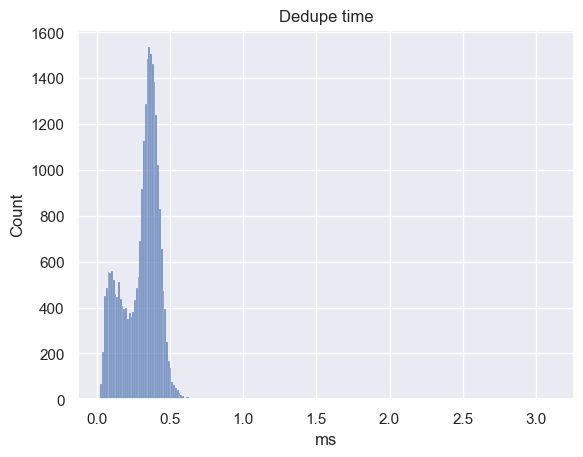

In [12]:
_ = sns.histplot(np.array(times_dedupe_sec) * 1_000).set(title="Dedupe time", xlabel="ms")

In [13]:
sum(times_dedupe_sec)

7.989940105180722

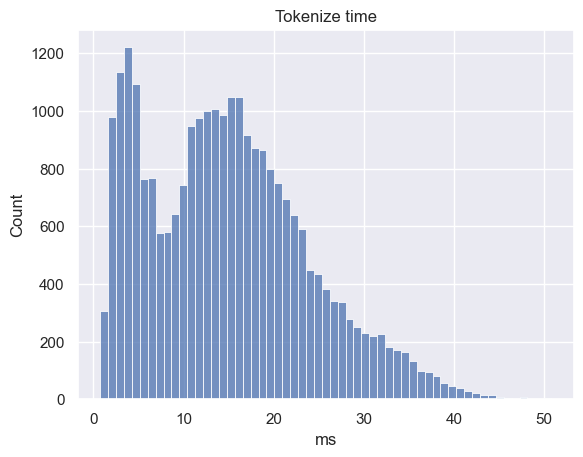

In [14]:
_ = sns.histplot(np.array(times_tokenize_sec) * 1_000).set(title="Tokenize time", xlabel="ms")

Likely we have a big set of small stacktraces.

In [15]:
sum(times_tokenize_sec)

391.87940487387823

2026-03-09 00:53:19,930 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-09 00:53:19,936 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


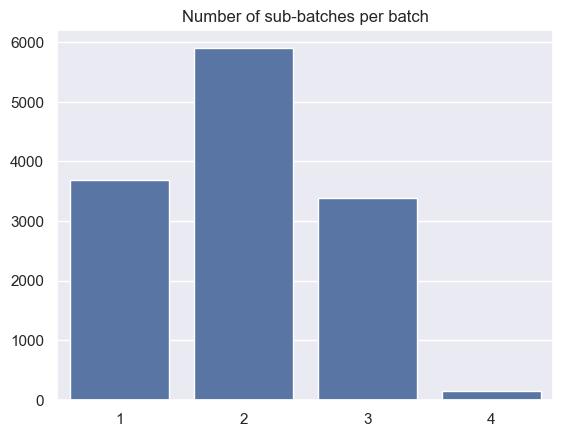

In [16]:
_ = sns.barplot(Counter(num_sub_batches_per_batch)).set(title="Number of sub-batches per batch")